In [3]:
#importing libraries
import pandas as pd
import numpy as np


In [4]:
# Loading dataset
df = pd.read_csv("Fraud.csv")

#  Checkfirst few rows
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (42271, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())



Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [6]:
#to know about missing values
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [7]:
#to drop missing values if any
df = df.dropna()

# Confirm no missing values left
print("Missing values after dropping:")
print(df.isnull().sum())

Missing values after dropping:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [8]:
# to Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")


Total duplicate rows: 0


In [9]:
#checking how many are frauds
print(df['isFraud'].value_counts())

isFraud
0.0    42176
1.0       94
Name: count, dtype: int64


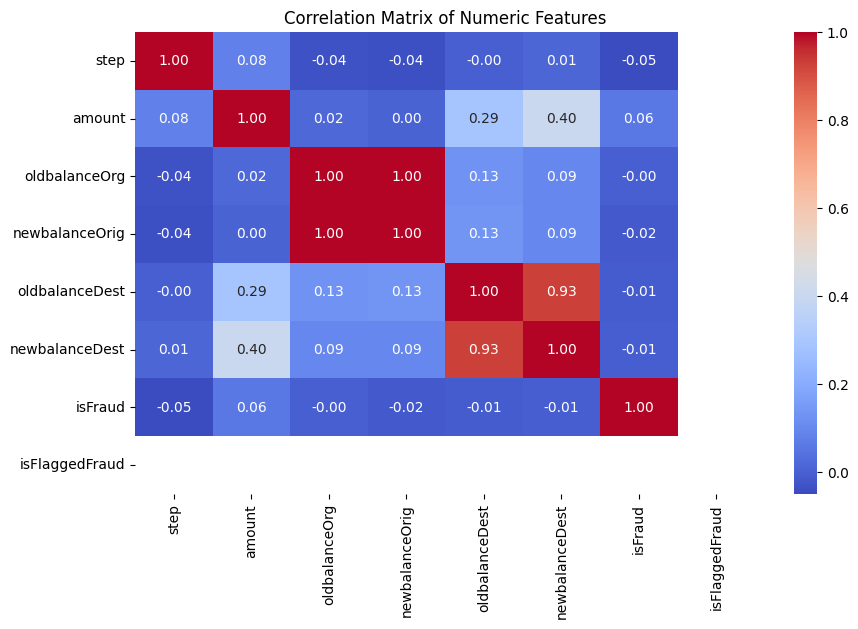

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
# Get numeric features only
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap#
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

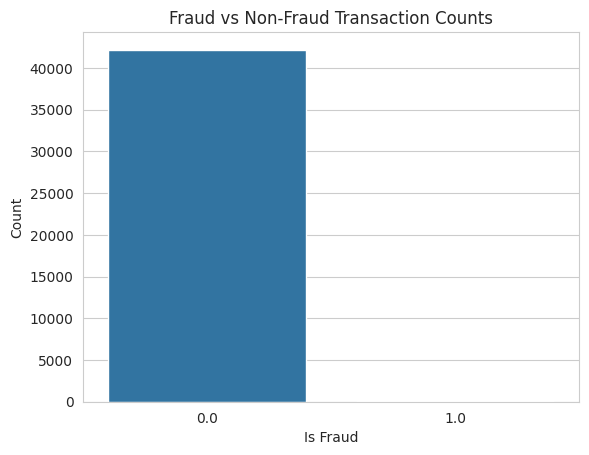

In [11]:
# Set style for better visuals
sns.set_style("whitegrid")

# Count plot
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transaction Counts')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

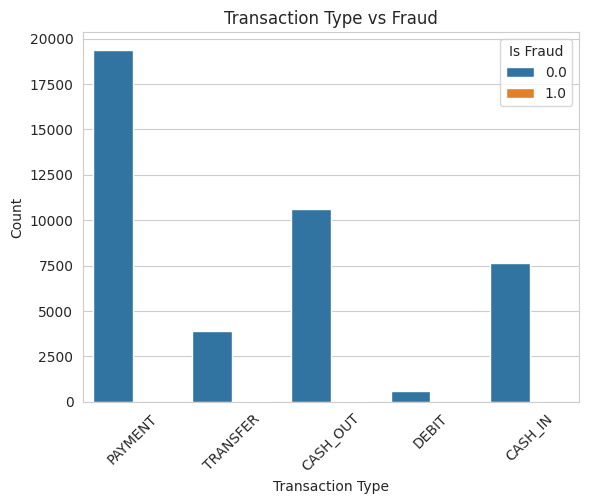

In [12]:
#trying to figure out the relation between Fraud and Transaction type
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Is Fraud')
plt.show()

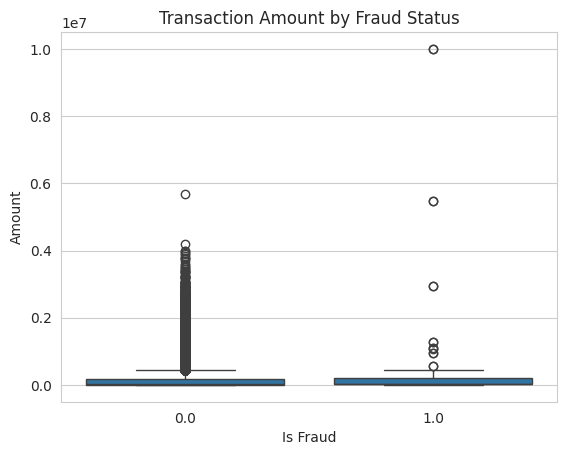

In [13]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.show()

In [14]:
# Summary stats for non-fraud
print(" Non-Fraud Summary:")
print(df[df['isFraud'] == 0]['amount'].describe())

# Summary stats for fraud
print("\n Fraud Summary:")
print(df[df['isFraud'] == 1]['amount'].describe())



 Non-Fraud Summary:
count    4.217600e+04
mean     1.481334e+05
std      3.043552e+05
min      1.770000e+00
25%      7.022842e+03
50%      2.750440e+04
75%      1.793812e+05
max      5.677662e+06
Name: amount, dtype: float64

 Fraud Summary:
count    9.400000e+01
mean     5.413771e+05
std      1.670973e+06
min      1.640000e+02
25%      1.401779e+04
50%      2.970786e+04
75%      2.077485e+05
max      1.000000e+07
Name: amount, dtype: float64


In [15]:
# Separate fraud and non-fraud
df_fraud = df[df['isFraud'] == 1]
df_nonfraud_sampled = df[df['isFraud'] == 0].sample(n=len(df_fraud), random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_fraud, df_nonfraud_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Confirm class distribution
print("Balanced Class Counts:")
print(df_balanced['isFraud'].value_counts())


Balanced Class Counts:
isFraud
0.0    94
1.0    94
Name: count, dtype: int64


In [16]:
#selecting only numeric values only
features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest']

X = df_balanced[features]
y = df_balanced['isFraud']

In [17]:
#splitting data into train and test
from sklearn.model_selection import train_test_split

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


In [18]:
#using Randomforestclassifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
#making predictions
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

# Evaluation metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        29
         1.0       0.89      0.89      0.89        28

    accuracy                           0.89        57
   macro avg       0.89      0.89      0.89        57
weighted avg       0.89      0.89      0.89        57

Confusion Matrix:
 [[26  3]
 [ 3 25]]


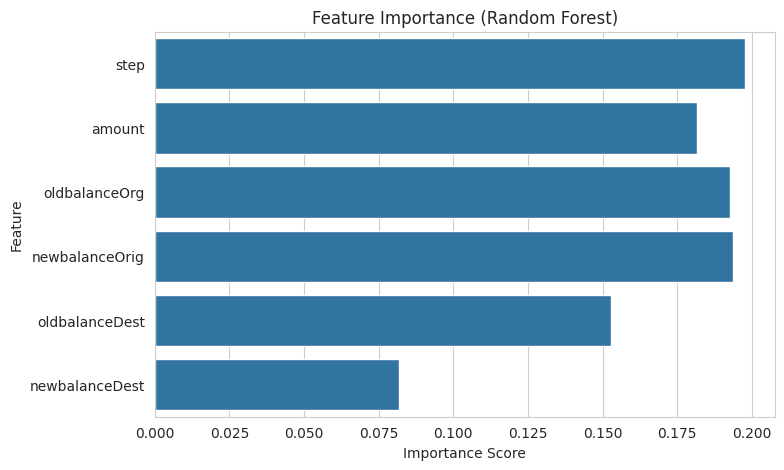

In [20]:
# Plot feature importances
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
